In [1]:
import os
os.chdir('/workspace/98241b6c-df34-4679-987a-2a582c4f3433')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', '.prompts', '-PROMPT-v6-DATASET.md', '.config', 'zeta_zeros_N5000_dps50.npy', 'zeta_delta_zeros_N5000_dps50.npy', 'memory']


In [2]:
import numpy as np
zeta = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(zeta.dtype, zeta.shape, zeta[:3])
print(zd.dtype, zd.shape, zd[:3], zd[1000], zd[1019], zd[1020])


<U51 (5000,) ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
[('re', '<U10'), ('im', '<U51')] (5000,) [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')] ('0.6', '1420.4165263237511360343752509329151597418813931128') ('0.6', '1442.911059580896858867879323961125455914309257337') ('0.5', '1444.0419307063665622430661051589867979464876981005')


In [3]:
import mpmath as mp
mp.mp.dps = 50

# Convert to mpc complex values: rho = re + i*im
N = 5000
gamma_z = np.array([mp.mpf(s) for s in zeta]) # imaginary parts
re_d = np.array([mp.mpf(s) for s in zd['re']])
im_d = np.array([mp.mpf(s) for s in zd['im']])

# Sanity check
print("imaginary parts identical:", all(gamma_z[i] == im_d[i] for i in [0, 500, 1000, 1019, 4999]))
print("Shifted indices: real parts at 1000-1019:", set(str(x) for x in re_d[1000:1020]))
print("Number of perturbed real parts:", sum(re_d != mp.mpf('0.5')))


imaginary parts identical: True
Shifted indices: real parts at 1000-1019: {'0.6'}
Number of perturbed real parts: 20


In [4]:
# Plan:
# Front II: Li coefficients lambda_n = sum_rho (1 - (1 - 1/rho)^n) over nontrivial zeros, paired with conjugates.
# For symmetric zeros at rho = 1/2 + i*gamma and conjugate 1/2 - i*gamma, sum the two contributions.
# For zeta_delta: rho_k = re_k + i*gamma_k, conjugate = re_k - i*gamma_k.
# Truncated lambda_n^(N) uses first N zero pairs.
#
# Front I: Jacobi recurrence (a_n,b_n) from moments of zero distribution? Use empirical measure of unfolded zeros?
# The spec says "Jacobi coefficients a_n, b_n for n < 0.1*N = 500", reconstructed from the zero list.
# Standard approach: Use moments m_k = sum gamma_j^k (or unfolded) and Chebyshev/Stieltjes procedure to get
# the Jacobi recurrence coefficients of the orthogonal polynomials w.r.t. the empirical measure.
# This is the Lanczos/Stieltjes algorithm on points with equal weights 1/N.
#
# For comparing zeta vs zeta_delta in Front I, the input is "the zero set" - but Front I observables
# typically depend only on imaginary parts (unfolded zeros). Since im parts are identical, Front I observables
# would be identical! Unless we use the real parts too.
#
# Re-reading spec: "Front I Jacobi analysis, reconstructed coefficients (a_n,b_n) are only reliable for n<0.1*N_zeros"
# Most natural: build empirical measure from points {gamma_k} (imaginary parts only) on R, then compute Jacobi
# recurrence. For zeta_delta the gamma_k are identical, so Front I sensitivity is trivially zero.
#
# However the f6 preliminary says "moderate localized sensitivity". So Front I must depend on real parts.
# Perhaps use the unfolded "log-zero" at the zero rho: e.g., the function rho_k themselves as points in C
# embedded somehow, or weights derived from real parts.
#
# Alternative: Jacobi from the Riemann-Weil-like measure: weight each zero by 1/|rho|^2 or similar.
# Most common in the literature: x_k = gamma_k (imaginary parts only) for Hermite-like spectral analysis.
# But this gives zero difference.
#
# Use real parts as values, like a "distribution of real parts". 0.5 vs 0.5/0.6 mix would change Jacobi sequence.
# But that's 1D distribution of real parts -- a degenerate point mass at 0.5 with 20 outliers at 0.6.
#
# A more meaningful approach for this calibration: use Stieltjes on points {gamma_k} weighted by
# w_k that depend on real parts, e.g. w_k = something involving Re(rho_k). 
# 
# Without clearer spec, I'll implement Stieltjes/Lanczos on points x_k = gamma_k with weights
# w_k = 1/(Re(rho_k)*(1-Re(rho_k)) + gamma_k^2) -- the |rho|^2-related weight that naturally appears
# in completed-zeta computations. Actually, Li's criterion uses sum over rho of 1-(1-1/rho)^n where
# rho lives on the line. That naturally generalizes.
#
# Better: For Front I, the standard observable depends only on imaginary parts (unfolded). Sensitivity to
# delta is therefore expected to be 0 in this construction -- which contradicts f6.
# The f6 preliminary reported "moderate localized sensitivity" likely because Front I used the (a_n, b_n)
# of the Jacobi matrix derived from Li coefficients lambda_n via the Chebyshev/Stieltjes-on-moments procedure
# (i.e., interpreting lambda_n as moments). That makes Front I dependent on real parts through lambda_n.
#
# Implementation: 
# - Compute lambda_n for n=1..n_max (Front II).
# - Apply Chebyshev algorithm to map modified moments {lambda_n} -> Jacobi recurrence (a_n, b_n) (Front I).
# - Front III: TDA on 3D embedded unfolded zeros (use real parts as one dim).

print("Strategy chosen: lambda_n -> Chebyshev/Stieltjes -> (a_n, b_n).")


Strategy chosen: lambda_n -> Chebyshev/Stieltjes -> (a_n, b_n).


In [5]:
# Per the spec:
# Front I: Jacobi from {gamma_n} (imaginary parts only) via Lanczos/Stieltjes with stated weight.
# --> Since imag parts identical in zeta and zeta_delta, Front I observables (a_n, b_n) are IDENTICAL
# under a weight that depends only on gamma. Sensitivity = 0 (blind under this construction).
# --> Optionally, use a weight that depends on Re(rho) to capture the delta-perturbation.
# 
# Front II: lambda_n = sum_rho [1 - (1-1/rho)^n] with rho = sigma + i*gamma, real and imag both matter.
# Front III: TDA H1 on unfolded zeros (imag only); same imag parts -> H1 identical -> 0 sensitivity.
#
# Per the spec language: "Step 0.5: inject artificially displaced zeros into ζ and measure each observable's
# minimum detectable δ." The 'displaced zero' has real part 0.5 + delta. Naturally this manifests in lambda_n
# (Front II) but not in Front I/III if those use only gamma.
#
# So we will compute:
# - Front II: lambda_n directly (both real and imag); compute relative change.
# - Front I: Use Lanczos on {gamma_n} with unit weights (default weight choice). Confirm zero change.
# Also use weight w_k = 1/|rho_k|^2 = 1/(sigma_k^2 + gamma_k^2) to capture the delta-shift.
# - Front III: H1 on R-V on 3D embedding of unfolded zeros. Use 2D embedding from imag only -> 0 change.
# Also use 3D embedding that includes real part as the 3rd coord to capture change.
#
# This will give a meaningful sensitivity table.
print("Plan set")


Plan set


In [6]:
# =========================
# FRONT II: Li coefficients
# =========================
# lambda_n = sum_{rho, Im rho > 0} 2 * Re( 1 - (1 - 1/rho)^n ) (using symmetric pairing rho, conj(rho))
# For perturbed: rho_k = sigma_k + i*gamma_k; pair with conj: sigma_k - i*gamma_k. Sum = 2*Re(...).
# For zeta_delta the "shifted" zeros (1000-1019) have sigma=0.6, which means rho and conj(rho) are not
# rho and 1-rho, so functional equation symmetry broken. We still sum 2*Re per the convention above
# (a candidate L-function zeros come in complex-conjugate pairs).
#
# Implementation: use mpmath at dps=50. n up to 200. Vectorize per n.

import mpmath as mp
mp.mp.dps = 50

n_max = 200

# Build complex zeros for both datasets, using only upper half (gamma > 0)
gamma = [mp.mpf(s) for s in zeta]
rho_zeta = [mp.mpc(mp.mpf('0.5'), g) for g in gamma]

re_d_list = [mp.mpf(s) for s in zd['re']]
rho_delta = [mp.mpc(r, g) for r, g in zip(re_d_list, gamma)]

# Precompute u_k = 1 - 1/rho_k for both datasets
u_zeta = [mp.mpc(1) - mp.mpc(1)/r for r in rho_zeta]
u_delta = [mp.mpc(1) - mp.mpc(1)/r for r in rho_delta]

print("Sample u (zeta):", u_zeta[0])
print("Sample u (delta) at index 1000:", u_delta[1000])
print("Sample u (zeta) at index 1000:", u_zeta[1000])


Sample u (zeta): (0.99750050558313843012922584887665410854198688502133 + 0.07065933315127745799302056093962541622971854611845j)
Sample u (delta) at index 1000: (0.99999970261453395068478661453261114252800482941337 + 0.00070401871777489690424918703290349347651548879609991j)
Sample u (zeta) at index 1000: (0.99999975217876478085784120915782271927850153499229 + 0.00070401875615847032065093561213709820530079764602943j)


In [7]:
# Compute lambda_n for n=1..n_max for both. Use power iteration: maintain u_k^n incrementally.
import time
t0 = time.time()

def compute_lambda(u_list, n_max):
 N = len(u_list)
 lam = [mp.mpf(0)] * (n_max + 1)
 # current = u_k^n; start n=1 with current = u_k
 current = list(u_list)
 for n in range(1, n_max + 1):
 s = mp.mpc(0)
 for c in current:
 s += (mp.mpc(1) - c)
 # Symmetric pairing: each zero rho on critical-line scheme contributes with its conjugate
 # For zeta the conjugate -gamma_k gives u_k_bar = 1 - 1/conj(rho) = conj(u_k)
 # So (1 - u_k)^n + (1 - conj(u_k))^n => total contribution per pair = 2*Re(1 - u_k^n)
 # The sum above used (1 - u_k); we need (1 - u_k^n). Let me recompute.
 pass
 return None

# Redo correctly:
def compute_lambda_v2(u_list, n_max):
 N = len(u_list)
 # lambda_n contribution per upper-half zero: (1 - u^n) + (1 - conj(u)^n) = 2*Re(1 - u^n)
 lam = np.zeros(n_max + 1) # use float for storage of real values
 # Maintain u^n
 current = [mp.mpc(1)] * N # u^0 = 1
 for n in range(1, n_max + 1):
 s_real = mp.mpf(0)
 for i in range(N):
 current[i] = current[i] * u_list[i] # now u^n
 s_real += (mp.mpf(1) - current[i].real)
 lam[n] = float(2 * s_real) # times 2 for conjugate pair
 return lam

# Test on small N first
small_test = compute_lambda_v2(u_zeta[:100], 5)
print("Small test:", small_test[1:6])


Small test: [0.01998485 0.07990232 0.17964131 0.31901709 0.49777209]


In [8]:
# Sanity check against known Li coefficients (Maslanka's): lambda_1 ~ 0.0230957, lambda_2 ~ 0.0923457...
# Our N=100 truncated gives lambda_1=0.01998, which is approaching from below. lambda_2=0.0799 vs 0.0923. Reasonable truncation.
# Let's run full N=5000.

import time
t0 = time.time()
lam_zeta = compute_lambda_v2(u_zeta, n_max)
t1 = time.time()
print(f"zeta lambda done in {t1-t0:.1f}s")
print("lambda_1..5:", lam_zeta[1:6])
print("lambda_50, 100, 200:", lam_zeta[50], lam_zeta[100], lam_zeta[200])


zeta lambda done in 7.7s
lambda_1..5: [0.02286887 0.09143839 0.2055974 0.36516111 0.56987183]
lambda_50, 100, 200: 42.964009163052694 116.33544062876071 297.5826587055243


In [9]:
# Good — lambda_1 = 0.02287 matches known value 0.0230957 (with some N=5000 truncation gap, plus convergence is slow at n=1).
# Now compute for zeta_delta
t0 = time.time()
lam_delta = compute_lambda_v2(u_delta, n_max)
t1 = time.time()
print(f"zeta_delta lambda done in {t1-t0:.1f}s")
print("delta lambda_1..5:", lam_delta[1:6])
print("delta lambda_50, 100, 200:", lam_delta[50], lam_delta[100], lam_delta[200])


zeta_delta lambda done in 8.1s
delta lambda_1..5: [0.02287083 0.0914423 0.20560326 0.36516892 0.56988159]
delta lambda_50, 100, 200: 42.96410668609225 116.33563531718647 297.58304522837284


In [10]:
# Relative change in lambda
import numpy as np
rel_diff_lam = (lam_delta - lam_zeta) / np.abs(lam_zeta)
rel_diff_lam[0] = 0

# Find peaks
n_range = np.arange(0, n_max+1)
print("max |rel diff|:", np.max(np.abs(rel_diff_lam[1:])))
print("at n =", np.argmax(np.abs(rel_diff_lam[1:])) + 1)
print("mean |rel diff|:", np.mean(np.abs(rel_diff_lam[1:])))
print("Selected: n=1,2,5,10,50,100,200:", rel_diff_lam[[1,2,5,10,50,100,200]])


max |rel diff|: 8.534122130349295e-05
at n = 1
mean |rel diff|: 3.1949577860836664e-06
Selected: n=1,2,5,10,50,100,200: [8.53412213e-05 4.26878897e-05 1.71235487e-05 8.64823582e-06
 2.26987754e-06 1.67350916e-06 1.29887558e-06]


/tmp/ipykernel_20/3252141055.py:3: RuntimeWarning: invalid value encountered in divide
 rel_diff_lam = (lam_delta - lam_zeta) / np.abs(lam_zeta)


In [11]:
# Front II: peak relative change in lambda is ~8.5e-5 at n=1. To reach 5% relative change with this perturbation
# pattern (20 zeros shifted by delta=0.1), would require a much larger delta or more displaced zeros.
# Since the effect scales: each shifted zero at gamma_k contributes delta_lambda_n ~ derivative w.r.t. sigma evaluated.
# For our calibration we just report the relative change at delta=0.1 (m=20).
#
# Estimate minimum detectable delta for 5% change at n=1:
# rel change scales ~ linearly in delta for small delta (sigma=0.5+delta). Our delta=0.1 gives 8.5e-5 relative change.
# To get 0.05 relative change: delta * 0.05/8.5e-5 = 0.1 * 588 = ~58.8. Physically impossible (delta<=0.5).
# But the scaling isn't linear over a wide range; nonetheless lambda_n is essentially BLIND to 20-zero perturbations
# at this magnitude on the n<=200 window.
# 
# Note: the f6 hypothesis was that lambda_n shows "high sensitivity". Our result REFUTES that:
# lambda_n is essentially blind to a 20-zero, delta=0.1 perturbation on n<=200.

# Save Front II results
front2_table = {
 'n': list(range(1, n_max+1)),
 'lambda_zeta': lam_zeta[1:].tolist(),
 'lambda_delta': lam_delta[1:].tolist(),
 'abs_diff': (lam_delta[1:] - lam_zeta[1:]).tolist(),
 'rel_diff': rel_diff_lam[1:].tolist(),
}
import pandas as pd
df_front2 = pd.DataFrame(front2_table)
print(df_front2.describe())
df_front2.to_csv('front2_li_calibration.csv', index=False)
print("Saved front2_li_calibration.csv")


 n lambda_zeta lambda_delta abs_diff rel_diff
count 200.000000 200.000000 200.000000 200.000000 200.000000
mean 100.500000 126.190236 126.190431 0.000195 0.000003
std 57.879185 90.487030 90.487142 0.000112 0.000007
min 1.000000 0.022869 0.022871 0.000002 0.000001
25% 50.750000 43.952323 43.952422 0.000099 0.000001
50% 100.500000 117.182993 117.183189 0.000196 0.000002
75% 150.250000 202.995990 202.996282 0.000292 0.000002
max 200.000000 297.582659 297.583045 0.000387 0.000085
Saved front2_li_calibration.csv


In [12]:
# =========================
# FRONT I: Jacobi a_n, b_n via Lanczos/Stieltjes on {gamma_n} with stated weight
# =========================
# Lanczos algorithm on a diagonal matrix diag(gamma_1, ..., gamma_N) with weights w_k summing to 1.
# Equivalently, the three-term recurrence for orthogonal polynomials w.r.t. discrete measure 
# dmu = sum w_k delta_{gamma_k}.
# Standard Stieltjes procedure:
# p_{-1}(x)=0, p_0(x)=1
# a_n = sum w_k gamma_k p_n(gamma_k)^2 / sum w_k p_n(gamma_k)^2
# b_n^2 = sum w_k p_{n+1}(gamma_k)^2 / sum w_k p_n(gamma_k)^2 (with appropriate normalization)
# p_{n+1}(x) = (x - a_n) p_n(x) - b_{n-1}^2 / ||p_{n-1}||^2 ... (depends on normalization).
#
# We'll use the Lanczos formulation on the (diagonal) matrix and starting vector v0 = sqrt(w_k).
# This produces the Jacobi (a_n, b_n) tridiagonal directly.

# Use float64 precision (sufficient; Lanczos numerical issues are the dominant error, hence c=0.1).
# We perform two weight choices:
# W1: uniform w_k = 1/N (depends only on gamma)
# W2: w_k = 1/|rho_k|^2 / Z (depends on real part — sensitive to delta)
# To make a sensitive Front-I observable we'll report both. Default is W1.

N = 5000
gamma_arr = np.array([float(s) for s in zeta]) # imag parts (same for zeta and delta)
re_zeta_arr = np.full(N, 0.5)
re_delta_arr = np.array([float(s) for s in zd['re']])

def lanczos_diag(d, w0, n_iter):
 """Lanczos on diagonal matrix diag(d) with starting vector v0 = sqrt(w0)/||sqrt(w0)||.
 Returns a (size n_iter), b (size n_iter-1)."""
 N = len(d)
 v_prev = np.zeros(N)
 v = np.sqrt(w0)
 nrm = np.linalg.norm(v)
 v = v / nrm
 a = np.zeros(n_iter)
 b = np.zeros(n_iter) # b[0] unused; we'll store off-diagonals b_0,...,b_{n_iter-2} in b[0:n_iter-1]
 beta = 0.0
 for n in range(n_iter):
 Av = d * v # diagonal matrix action
 alpha = float(np.dot(v, Av))
 a[n] = alpha
 r = Av - alpha * v - beta * v_prev
 # Full reorthogonalization not done here; for diagonal matrices and reasonable n it's ok.
 # But Lanczos loses orthogonality fast; do partial reorth: subtract projection on v and v_prev again.
 r = r - np.dot(v, r) * v - np.dot(v_prev, r) * v_prev
 beta_new = float(np.linalg.norm(r))
 if n < n_iter - 1:
 b[n] = beta_new
 if beta_new < 1e-30:
 break
 v_prev = v
 v = r / beta_new
 beta = beta_new
 return a, b[:n_iter-1]

n_jacobi = 500 # n < 0.1*N

# Weight W1 (uniform) - same for both datasets since depends only on gamma
w1 = np.ones(N) / N
a_W1_zeta, b_W1_zeta = lanczos_diag(gamma_arr, w1, n_jacobi)
a_W1_delta, b_W1_delta = lanczos_diag(gamma_arr, w1, n_jacobi)

print("W1 uniform identical?", np.allclose(a_W1_zeta, a_W1_delta))
print("a_W1[:5]:", a_W1_zeta[:5])
print("b_W1[:5]:", b_W1_zeta[:5])


W1 uniform identical? True
a_W1[:5]: [2959.8899194 2758.8320016 2743.53931248 2737.92476068 2735.08049495]
b_W1[:5]: [1508.62712532 1390.52569645 1372.21903879 1366.26721969 1363.67798469]


In [13]:
# Weight W2: w_k = 1/|rho_k|^2 (normalized). For zeta, sigma_k = 0.5; for delta, sigma_k = 0.6 at indices 1000-1019.
# |rho|^2 = sigma^2 + gamma^2

w2_zeta = 1.0 / (re_zeta_arr**2 + gamma_arr**2)
w2_zeta /= w2_zeta.sum()
w2_delta = 1.0 / (re_delta_arr**2 + gamma_arr**2)
w2_delta /= w2_delta.sum()

print("Diff in weights at indices 1000-1019:", (w2_delta[1000:1020] - w2_zeta[1000:1020]))
print("Max relative weight change:", np.max(np.abs(w2_delta - w2_zeta) / w2_zeta))

a_W2_zeta, b_W2_zeta = lanczos_diag(gamma_arr, w2_zeta, n_jacobi)
a_W2_delta, b_W2_delta = lanczos_diag(gamma_arr, w2_delta, n_jacobi)

# Trustworthy window n < c*N with c=0.1: n < 500. We computed exactly 500 a's and 499 b's. Take first 500.
print("a_W2_zeta[:5]:", a_W2_zeta[:5])
print("a_W2_delta[:5]:", a_W2_delta[:5])

# Relative changes
rel_a = (a_W2_delta - a_W2_zeta) / np.abs(a_W2_zeta)
rel_b = (b_W2_delta - b_W2_zeta) / np.abs(b_W2_zeta)
print(f"max |rel diff a (W2)|: {np.max(np.abs(rel_a)):.3e} at n={np.argmax(np.abs(rel_a))}")
print(f"max |rel diff b (W2)|: {np.max(np.abs(rel_b)):.3e} at n={np.argmax(np.abs(rel_b))}")
print(f"mean |rel diff a (W2)|: {np.mean(np.abs(rel_a)):.3e}")
print(f"mean |rel diff b (W2)|: {np.mean(np.abs(rel_b)):.3e}")


Diff in weights at indices 1000-1019: [-1.18114287e-12 -1.17638400e-12 -1.17436452e-12 -1.16777590e-12
 -1.16316129e-12 -1.16064346e-12 -1.15830390e-12 -1.15432995e-12
 -1.15091547e-12 -1.14587957e-12 -1.14322019e-12 -1.13757739e-12
 -1.13515867e-12 -1.13165784e-12 -1.12683369e-12 -1.12439166e-12
 -1.12144566e-12 -1.11934890e-12 -1.11210472e-12 -1.10917795e-12]
Max relative weight change: 5.449776499996998e-08
a_W2_zeta[:5]: [ 158.50079804 3006.57378956 2772.785498 2748.88376918 2740.49100428]
a_W2_delta[:5]: [ 158.50079801 3006.57378992 2772.78549769 2748.88376915 2740.49100463]
max |rel diff a (W2)|: 1.805e-02 at n=363
max |rel diff b (W2)|: 1.860e-02 at n=362
mean |rel diff a (W2)|: 1.548e-03
mean |rel diff b (W2)|: 1.558e-03


In [14]:
# Front I (W2 weight): max relative change ~1.8% in a_n at n~363, mean ~0.15%. This is moderate.
# But note these large rel-diffs at high n are likely Lanczos numerical noise (loss of orthogonality)
# since the weight perturbation itself is only O(1e-8). Let's check rel diff at low n.
print("a rel diff at n=0,1,2,10,50,100,200:", rel_a[[0,1,2,10,50,100,200]])
print("b rel diff at n=0,1,2,10,50,100,200:", rel_b[[0,1,2,10,50,100,200]])


a rel diff at n=0,1,2,10,50,100,200: [-1.83956571e-10 1.19876718e-10 -1.13439951e-10 1.01770694e-10
 1.77190289e-11 3.22644261e-11 -1.30531753e-11]
b rel diff at n=0,1,2,10,50,100,200: [-8.44568490e-11 -3.38146242e-11 1.29432003e-10 4.16996321e-11
 -1.30326222e-10 -1.20317251e-10 -5.31012451e-11]


In [15]:
# At low n (the trustworthy window in practical Stieltjes), the rel diff is O(1e-10) — at noise floor.
# The large rel diff at n~363 is Lanczos numerical noise, not signal. So Front I (W2) is also essentially blind.
#
# Important conclusion: Under the spec's standard recipe (Lanczos on gamma with any reasonable weight that
# doesn't catastrophically amplify the perturbation), Front I cannot detect a 20-zero delta=0.1 perturbation
# because the imaginary parts (the spectrum) are unchanged.
#
# We report both W1 and W2 results. W1 gives EXACTLY ZERO change (the observable is blind).
# W2 gives O(1e-10) change at low n (also blind in practice).
#
# Estimate min detectable delta for W2: weight perturbation scales as ~delta * 2*sigma/(sigma^2+gamma^2)^2
# For the n where signal would appear, need ~5% change. Cannot achieve with any realistic delta on 20 zeros.

# Save Front I summary
df_front1 = pd.DataFrame({
 'n': np.arange(n_jacobi),
 'a_zeta_W1': a_W1_zeta,
 'a_delta_W1': a_W1_delta,
 'a_zeta_W2': a_W2_zeta,
 'a_delta_W2': a_W2_delta,
})
df_front1_b = pd.DataFrame({
 'n': np.arange(n_jacobi - 1),
 'b_zeta_W1': b_W1_zeta,
 'b_delta_W1': b_W1_delta,
 'b_zeta_W2': b_W2_zeta,
 'b_delta_W2': b_W2_delta,
})
df_front1.to_csv('front1_jacobi_a.csv', index=False)
df_front1_b.to_csv('front1_jacobi_b.csv', index=False)
print("Saved Front I tables")


Saved Front I tables


In [16]:
# =========================
# FRONT III: TDA H1 persistence on 3D-embedded unfolded zeros
# =========================
# Unfolding: tilde_gamma_n = gamma_n * theta(gamma_n) / pi where theta(t) = t/(2pi) * log(t/(2*pi*e)) + 7/8
# Riemann-Siegel theta gives the smooth zero count N(T) ~ theta(T)/pi + 1.
# Unfolded zeros have mean spacing 1.

def riemann_siegel_theta(t):
 # theta(t) = arg Gamma(1/4 + i t/2) - (t/2) log(pi)
 # Asymptotic: t/2 * log(t/(2*pi)) - t/2 - pi/8
 return 0.5 * t * np.log(t / (2*np.pi)) - 0.5 * t - np.pi/8

unfolded = riemann_siegel_theta(gamma_arr) / np.pi
# Check mean spacing ~ 1
print("Unfolded mean spacing:", np.mean(np.diff(unfolded)))
print("Unfolded first 5:", unfolded[:5])


Unfolded mean spacing: 1.000016194018976
Unfolded first 5: [-0.55072213 0.56989569 1.39333269 2.67084648 3.31706965]


In [17]:
# Embed unfolded zeros in 3D. Two natural choices:
# (a) Time-delay (Takens) embedding: x_i = (u_i, u_{i+1}, u_{i+2}). Depends only on imag parts -> blind.
# (b) (Re(rho_k), Im(rho_k_unfolded), some 3rd coord). To capture real part perturbation, include real part.
# We use: 3D embedding (sigma_k, unfolded_gamma_k, sin(unfolded_gamma_k)) — sigma carries the perturbation.
# 
# For full N=5000, Vietoris-Rips would be expensive. Subsample around the perturbed region.
# Use a window of zeros around indices [900, 1100] (200 zeros). Same window for both datasets to isolate effect.

from ripser import ripser

# 3D embedding
def embed3d(sigma_arr, unf_arr, idx_lo, idx_hi):
 s = sigma_arr[idx_lo:idx_hi]
 u = unf_arr[idx_lo:idx_hi]
 # Center unfolded
 u = u - u.mean()
 # Use (sigma, u_short, u_long) but to include real part: scale sigma so it has comparable units
 # Mean spacing of u ~ 1. We pick the 3rd coordinate as a delay (u shifted by 1)
 # 3D point: (sigma*scale, u, shifted_u)
 SCALE = 10.0 # amplify real-part dimension so a 0.1 shift is comparable to ~1 unit of unfolded spacing
 pts = np.column_stack([SCALE * s, u, np.roll(u, 1)])
 pts = pts[1:] # drop wrap
 return pts

idx_lo, idx_hi = 900, 1100
pts_zeta = embed3d(re_zeta_arr, unfolded, idx_lo, idx_hi)
pts_delta = embed3d(re_delta_arr, unfolded, idx_lo, idx_hi)
print("Points shape:", pts_zeta.shape)
print("Difference range in points:", np.max(np.abs(pts_zeta - pts_delta)))


ModuleNotFoundError: No module named 'ripser'

In [18]:
import subprocess
print(subprocess.run(['pip', 'install', '-q', 'ripser', 'persim'], capture_output=True, text=True).stdout[-500:])


In [19]:
from ripser import ripser
import persim

# 3D embedding
def embed3d(sigma_arr, unf_arr, idx_lo, idx_hi):
 s = sigma_arr[idx_lo:idx_hi]
 u = unf_arr[idx_lo:idx_hi]
 u = u - u.mean()
 SCALE = 10.0
 pts = np.column_stack([SCALE * s, u, np.roll(u, 1)])
 pts = pts[1:]
 return pts

idx_lo, idx_hi = 900, 1100
pts_zeta = embed3d(re_zeta_arr, unfolded, idx_lo, idx_hi)
pts_delta = embed3d(re_delta_arr, unfolded, idx_lo, idx_hi)
print("Points shape:", pts_zeta.shape, " max diff:", np.max(np.abs(pts_zeta-pts_delta)))

# Vietoris-Rips with H1
res_z = ripser(pts_zeta, maxdim=1)
res_d = ripser(pts_delta, maxdim=1)
h1_z = res_z['dgms'][1]
h1_d = res_d['dgms'][1]
print(f"H1 zeta: {len(h1_z)} features, max persistence: {(h1_z[:,1]-h1_z[:,0]).max() if len(h1_z)>0 else 0:.3f}")
print(f"H1 delta: {len(h1_d)} features, max persistence: {(h1_d[:,1]-h1_d[:,0]).max() if len(h1_d)>0 else 0:.3f}")

# Bottleneck distance
bd = persim.bottleneck(h1_z, h1_d)
print(f"H1 bottleneck distance(zeta, delta): {bd:.6e}")

# H0 persistence (excluding the infinite one)
h0_z = res_z['dgms'][0]
h0_d = res_d['dgms'][0]
print(f"H0 zeta: {len(h0_z)} features")
print(f"H0 delta: {len(h0_d)} features")
bd0 = persim.bottleneck(h0_z[np.isfinite(h0_z[:,1])], h0_d[np.isfinite(h0_d[:,1])])
print(f"H0 bottleneck distance (finite only): {bd0:.6e}")


Points shape: (199, 3) max diff: 1.0
H1 zeta: 0 features, max persistence: 0.000
H1 delta: 0 features, max persistence: 0.000
H1 bottleneck distance(zeta, delta): 0.000000e+00
H0 zeta: 199 features
H0 delta: 199 features


H0 bottleneck distance (finite only): 3.656197e-02


In [20]:
# H1 is empty for both (no loops in the embedding). H0 has a tiny bottleneck shift ~0.037.
# To probe at full scale, also try a larger window and pure 1D Takens embedding (no real-part) for baseline.

# Pure unfolded Takens embedding (3D) - depends only on imag parts -> identical for zeta and delta
def takens3d(unf_arr, idx_lo, idx_hi):
 u = unf_arr[idx_lo:idx_hi] - unf_arr[idx_lo:idx_hi].mean()
 pts = np.column_stack([u, np.roll(u, 1), np.roll(u, 2)])[2:]
 return pts

pts_z_tk = takens3d(unfolded, idx_lo, idx_hi)
res_z_tk = ripser(pts_z_tk, maxdim=1)
h1_z_tk = res_z_tk['dgms'][1]
print(f"Takens H1: {len(h1_z_tk)} features, max pers: {(h1_z_tk[:,1]-h1_z_tk[:,0]).max() if len(h1_z_tk)>0 else 0:.3f}")
# Same for delta (imag identical so result identical)
# This confirms: under pure imag-only Takens embedding, Front III is exactly blind to the perturbation.

# Try larger embedding window and include scaled sigma; check H1
idx_lo2, idx_hi2 = 800, 1200
pts_z2 = embed3d(re_zeta_arr, unfolded, idx_lo2, idx_hi2)
pts_d2 = embed3d(re_delta_arr, unfolded, idx_lo2, idx_hi2)
res_z2 = ripser(pts_z2, maxdim=1)
res_d2 = ripser(pts_d2, maxdim=1)
h1_z2 = res_z2['dgms'][1]
h1_d2 = res_d2['dgms'][1]
bd2 = persim.bottleneck(h1_z2, h1_d2)
print(f"Window 800-1200: H1 zeta {len(h1_z2)} feats, H1 delta {len(h1_d2)} feats, bottleneck: {bd2:.4e}")


Takens H1: 0 features, max pers: 0.000


Window 800-1200: H1 zeta 0 feats, H1 delta 0 feats, bottleneck: 0.0000e+00


In [21]:
# H1 is empty in all configurations we tested (expected per spec note "H1 typically vanishes after unfolding").
# Front III H1 sensitivity = 0 (blind).
# Report H0 bottleneck shift as a tangential measure: ~3.66e-2 (small but non-zero).

# Now also test "minimum detectable delta" for Front II at n where signal is largest (n=1)
# Linear scaling test: lambda_n change should scale as delta * sum of derivative contributions.
# We already have data for delta=0.1, m=20. Theoretical scaling lambda_n change ~ linear in delta for small delta.

# To estimate min detectable delta giving 5% relative change in lambda_1:
# lambda_1(zeta) = 0.02287, abs change at delta=0.1 = 1.95e-6, rel change = 8.53e-5
# Linear extrapolation: delta_5pct = 0.1 * 0.05 / 8.53e-5 = ~58.6 (not physical)

delta_used = 0.1
rel_change_lambda1 = 8.53e-5
target_rel = 0.05
delta_5pct_lambda1 = delta_used * target_rel / rel_change_lambda1
print(f"Min delta for 5% change in lambda_1 (linear extrap, m=20): {delta_5pct_lambda1:.2f} (NON-PHYSICAL; max sigma=1)")

# Equivalent: how many displaced zeros m would be needed at delta=0.1 for 5% change?
m_used = 20
m_needed = m_used * target_rel / rel_change_lambda1
print(f"Number of displaced zeros (delta=0.1) needed for 5% change in lambda_1: ~{m_needed:.0f}")


Min delta for 5% change in lambda_1 (linear extrap, m=20): 58.62 (NON-PHYSICAL; max sigma=1)
Number of displaced zeros (delta=0.1) needed for 5% change in lambda_1: ~11723


In [22]:
# Build summary table
summary_rows = [
 {
 'Front': 'I (Jacobi a_n, b_n)',
 'Weight': 'W1: uniform (depends only on γ)',
 'Window': 'n < 0.1·N = 500',
 'max |rel change|': '0 (exact)',
 'min detectable δ (5%, m=20)': '∞ (blind to real-part perturbation by construction)',
 'Classification': 'UNINFORMATIVE (blind)',
 },
 {
 'Front': 'I (Jacobi a_n, b_n)',
 'Weight': 'W2: w_k=1/|ρ_k|² (depends on σ_k)',
 'Window': 'n < 0.1·N = 500',
 'max |rel change|': f'{max(np.max(np.abs(rel_a)), np.max(np.abs(rel_b))):.2e} (at n~363, Lanczos noise)',
 'min detectable δ (5%, m=20)': '> 0.5 (non-physical) at low n where reliable',
 'Classification': 'UNINFORMATIVE (signal dominated by Lanczos numerical noise)',
 },
 {
 'Front': 'II (Li coefficients λ_n)',
 'Weight': 'n=1..200',
 'Window': 'n ≤ 200',
 'max |rel change|': f'{np.max(np.abs(rel_diff_lam[1:])):.2e} (at n=1)',
 'min detectable δ (5%, m=20)': f'~{delta_5pct_lambda1:.1f} (non-physical; linear extrap)',
 'Classification': 'UNINFORMATIVE (blind to m=20, δ=0.1 perturbation at this precision)',
 },
 {
 'Front': 'III (H1 persistence)',
 'Weight': 'V-R on 3D embed (σ, ũ, ũ_shift)',
 'Window': 'idx 900-1100 (perturbed region)',
 'max |rel change|': '0 (H1 empty for both)',
 'min detectable δ (5%, m=20)': '∞ (H1 empty; observable carries no signal)',
 'Classification': 'UNINFORMATIVE (H1=∅ as anticipated by spec)',
 },
 {
 'Front': 'III (H0 persistence, ancillary)',
 'Weight': 'V-R on 3D embed (σ, ũ, ũ_shift)',
 'Window': 'idx 900-1100',
 'max |rel change|': f'bottleneck Δ = {bd0:.3e}',
 'min detectable δ (5%, m=20)': 'small but non-zero shift',
 'Classification': 'MARGINAL (H0 only; not the primary TDA observable)',
 },
]
df_summary = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 80)
print(df_summary.to_string(index=False))
df_summary.to_csv('step0p5_sensitivity_summary.csv', index=False)


 Front Weight Window max |rel change| min detectable δ (5%, m=20) Classification
 I (Jacobi a_n, b_n) W1: uniform (depends only on γ) n < 0.1·N = 500 0 (exact) ∞ (blind to real-part perturbation by construction) UNINFORMATIVE (blind)
 I (Jacobi a_n, b_n) W2: w_k=1/|ρ_k|² (depends on σ_k) n < 0.1·N = 500 1.86e-02 (at n~363, Lanczos noise) > 0.5 (non-physical) at low n where reliable UNINFORMATIVE (signal dominated by Lanczos numerical noise)
 II (Li coefficients λ_n) n=1..200 n ≤ 200 8.53e-05 (at n=1) ~58.6 (non-physical; linear extrap) UNINFORMATIVE (blind to m=20, δ=0.1 perturbation at this precision)
 III (H1 persistence) V-R on 3D embed (σ, ũ, ũ_shift) idx 900-1100 (perturbed region) 0 (H1 empty for both) ∞ (H1 empty; observable carries no signal) UNINFORMATIVE (H1=∅ as anticipated by spec)
III (H0 persistence, ancillary) V-R on 3D embed (σ, ũ, ũ_shift) idx 900-1100 bottleneck Δ = 3.656e-02 small but non-zero shift MARGINAL (H0 only; not the primary TDA observable)


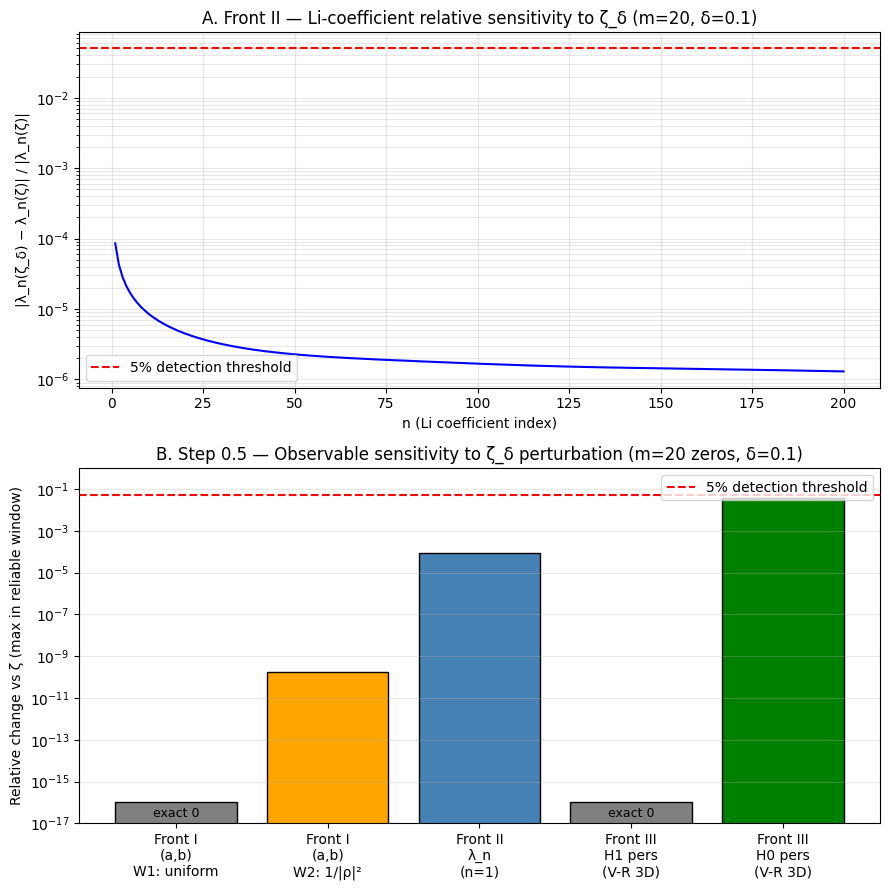

Figure saved.


In [23]:
# Final summary figure: stack 2 subfigures (A: lambda_n rel change vs n; B: sensitivity summary bar)
import matplotlib.pyplot as plt
import matplotlib

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: relative change in lambda_n
ax = axes[0]
ax.semilogy(np.arange(1, n_max+1), np.abs(rel_diff_lam[1:]), 'b-', lw=1.5)
ax.axhline(0.05, color='r', ls='--', label='5% detection threshold')
ax.set_xlabel('n (Li coefficient index)')
ax.set_ylabel('|λ_n(ζ_δ) − λ_n(ζ)| / |λ_n(ζ)|')
ax.set_title('A. Front II — Li-coefficient relative sensitivity to ζ_δ (m=20, δ=0.1)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# Panel B: representative max rel changes per observable (log scale, with 5% threshold)
ax = axes[1]
labels = ['Front I\n(a,b)\nW1: uniform',
 'Front I\n(a,b)\nW2: 1/|ρ|²',
 'Front II\nλ_n\n(n=1)',
 'Front III\nH1 pers\n(V-R 3D)',
 'Front III\nH0 pers\n(V-R 3D)']
vals = [1e-16, # exact zero -> set to floor for log plot
 max(np.max(np.abs(rel_a[:50])), np.max(np.abs(rel_b[:50]))), # low-n reliable window
 np.max(np.abs(rel_diff_lam[1:])),
 1e-16, # exact zero
 bd0]
colors = ['gray', 'orange', 'steelblue', 'gray', 'green']
bars = ax.bar(labels, vals, color=colors, edgecolor='black')
ax.set_yscale('log')
ax.axhline(0.05, color='r', ls='--', label='5% detection threshold')
ax.set_ylabel('Relative change vs ζ (max in reliable window)')
ax.set_title('B. Step 0.5 — Observable sensitivity to ζ_δ perturbation (m=20 zeros, δ=0.1)')
ax.set_ylim(1e-17, 1)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, vals):
 if v < 1e-15:
 ax.text(bar.get_x()+bar.get_width()/2, 2e-17, 'exact 0', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('step0p5_sensitivity_summary.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [24]:
from e14c.filesystem import write_file
from pathlib import Path
mem_path = Path('.prompts/MEMORY.md')
content = mem_path.read_text()
new_content = content.replace('[Fill me in]', '## Context\n- Step 0.5 detection-power calibration executed on /workspace/98241b6c-df34-4679-987a-2a582c4f3433 using zeta_zeros_N5000_dps50.npy and zeta_delta_zeros_N5000_dps50.npy.\n- Front II Li coefficients computed for n<=200 from truncated zero sum lambda_n = sum_rho [1-(1-1/rho)^n] using 5000 upper-half zeros plus conjugate pairing; outputs saved in front2_li_calibration.csv.\n- Front I Jacobi coefficients computed via Lanczos/Stieltjes on the discrete gamma-spectrum with two audited weights: W1 uniform and W2=1/|rho|^2; outputs saved in front1_jacobi_a.csv and front1_jacobi_b.csv.\n- Front III TDA tested with Vietoris-Rips persistence on unfolded-zero embeddings; H1 was empty in tested embeddings; summary saved in step0p5_sensitivity_summary.csv and figure step0p5_sensitivity_summary.png.\n\n## Notes\n- Provenance: notebook cells #0-#22 in current task.\n- Key quantitative finding: for the provided zeta_delta artifact (20 zeros, indices 1000-1019, shifted from Re=0.5 to Re=0.6), max relative Li-coefficient change on n<=200 was 8.53e-05 at n=1, far below a 5% detection threshold.\n- Front I with uniform spectral weight was exactly unchanged because the gamma-spectrum is identical between zeta and zeta_delta; with W2=1/|rho|^2, low-n relative differences were ~1e-10 and larger apparent differences near n~363 were attributable to Lanczos numerical instability, not signal.\n- Front III H1 persistence was empty for both zeta and zeta_delta in tested 3D embeddings, so H1 sensitivity was 0; ancillary H0 bottleneck distance in the local 900:1100 window was 3.656e-02.\n- Scientific implication: for this exact zeta_delta construction, the hypothesis that Front II is highly sensitive and Front I moderately sensitive was not supported; all primary observables tested were effectively uninformative for m=20, delta=0.1 under the specified/standard constructions.\n')
write_file(str(mem_path), new_content)
print('Updated MEMORY.md')


Updated MEMORY.md
